In [2]:
# ==== Célula 1 - Instalação de bibliotecas ====
!pip install newspaper3k "lxml[html_clean]" nltk wordcloud matplotlib pyspark --quiet

# ==== Célula 2 - Importações ====
import nltk
nltk.download('punkt')
nltk.download('stopwords')

import re
from newspaper import Article, build
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, col, lower

import requests
from urllib.parse import urlparse

# ==== Célula 3 - Função para verificar se o site é válido ====
def verificar_site(url):
    if not url.startswith("http"):
        url = "https://" + url
    try:
        response = requests.get(url, timeout=5)
        if response.status_code != 200:
            return False
        dominio = urlparse(url).netloc.lower()
        tlds_suspeitos = ('.x', '.tk', '.ml', '.ga', '.cf', '.gq')
        if dominio.endswith(tlds_suspeitos):
            return False
        return True
    except Exception:
        return False

# ==== Célula 4 - Lista de sites de notícias ====
news_sites = [
    "https://www.cnnbrasil.com.br",
    "https://g1.globo.com",
    "https://www.bbc.com/portuguese",
    "https://www.uol.com.br",
    "https://www.terra.com.br",
    "https://www.estadao.com.br",
    "https://www1.folha.uol.com.br",
    "https://noticias.uol.com.br",
    "https://ultimosegundo.ig.com.br",
    "https://exame.com",
    "https://jovempan.com.br",
    "https://oglobo.globo.com",
    "https://valor.globo.com",
    "https://www.correiobraziliense.com.br",
    "https://www.zh.clicrbs.com.br"
]

# ==== Célula 5 - Verifica e imprime sites válidos e inválidos ====
print("\ud83d\udd0e Verificando sites de notícias...\n")

sites_validos = []
for site in news_sites:
    if verificar_site(site):
        print(f"✅ Válido: {site}")
        sites_validos.append(site)
    else:
        print(f"❌ Inválido: {site}")

print(f"\n🔢 Total de sites válidos: {len(sites_validos)}")

# ==== Célula 6 - Inicializa SparkSession ====
spark = SparkSession.builder.appName("BigDataNoticias").getOrCreate()


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 50.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.0 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7d60311ea620>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.11/dist-packages/jupyter_client/session.py", line 742, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/jupyter_client/session.py", line 630, in serialize
    content = self.pack(content)
              ^^^^^^^^^^^^^^^^

✅ Válido: https://www.cnnbrasil.com.br
✅ Válido: https://g1.globo.com
✅ Válido: https://www.bbc.com/portuguese
✅ Válido: https://www.uol.com.br
✅ Válido: https://www.terra.com.br
✅ Válido: https://www.estadao.com.br
✅ Válido: https://www1.folha.uol.com.br
✅ Válido: https://noticias.uol.com.br
✅ Válido: https://ultimosegundo.ig.com.br
✅ Válido: https://exame.com
✅ Válido: https://jovempan.com.br
✅ Válido: https://oglobo.globo.com
✅ Válido: https://valor.globo.com
✅ Válido: https://www.correiobraziliense.com.br
❌ Inválido: https://www.zh.clicrbs.com.br

🔢 Total de sites válidos: 14


In [3]:
 #Função para coletar títulos com newspaper3k
def coletar_titulos(site_url, max_articles=30):
    titulos = []
    try:
        paper = build(site_url, memoize_articles=False)
        for article in paper.articles[:max_articles]:
            try:
                article.download()
                article.parse()
                titulos.append(article.title)
            except:
                continue
    except:
        print(f"Erro ao processar o site: {site_url}")
    return titulos

In [4]:
# Coleta de títulos
todos_titulos = []
for site in news_sites:
    print(f"Coletando de: {site}")
    titulos = coletar_titulos(site)
    todos_titulos.extend(titulos)
    print(f"Títulos coletados: {len(titulos)}")

# Pandas DataFrame com títulos
df = pd.DataFrame(todos_titulos, columns=["titulo"])

Coletando de: https://www.cnnbrasil.com.br


CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://www.cnnbrasil.com.br/feeds/


Títulos coletados: 30
Coletando de: https://g1.globo.com


CRITICAL:newspaper.network:[REQUEST FAILED] ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://especiaispublicitarios.g1.globo.com/
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://especiais.g1.globo.com/
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: http://especiais.g1.globo.com/
...
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://g1.globo.com/rss/
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://g1.globo.com/feed/
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://g1.globo.com/feeds/


Títulos coletados: 30
Coletando de: https://www.bbc.com/portuguese


...

Títulos coletados: 28
Coletando de: https://www.correiobraziliense.com.br


CRITICAL:newspaper.network:[REQUEST FAILED] 403 Client Error: Forbidden for url: https://assine.correiobraziliense.net.br/
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://www.correiobraziliense.com.br/rss
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://www.correiobraziliense.com.br/feeds


Títulos coletados: 30
Coletando de: https://www.zh.clicrbs.com.br


CRITICAL:newspaper.extractors:Must extract urls from either html, text or doc!
CRITICAL:newspaper.network:[REQUEST FAILED] HTTPSConnectionPool(host='www.zh.clicrbs.com.br', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'www.zh.clicrbs.com.br'. (_ssl.c:1016)")))
CRITICAL:newspaper.network:[REQUEST FAILED] HTTPSConnectionPool(host='www.zh.clicrbs.com.br', port=443): Max retries exceeded with url: /feed (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'www.zh.clicrbs.com.br'. (_ssl.c:1016)")))
CRITICAL:newspaper.network:[REQUEST FAILED] HTTPSConnectionPool(host='www.zh.clicrbs.com.br', port=443): Max retries exceeded with url: /feeds (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate veri

Títulos coletados: 0


In [14]:
import pandas as pd
import nltk
from google.colab import drive
from pyspark.sql.functions import col, split, explode, lower
from pyspark.sql import SparkSession
import json
from google.colab import drive
drive.mount('/content/drive')


# Montar o Google Drive
drive.mount('/content/drive')

# Inicializar Spark
spark = SparkSession.builder.appName("limpezaTexto").getOrCreate()

# Baixar stopwords do NLTK
nltk.download('stopwords')
stopwords_nltk = set(nltk.corpus.stopwords.words('portuguese'))

# Stopwords personalizadas
stopwords_personalizadas = {
    "do", "de", "que", "como", "onde", "não", "é", "a", "an", "ou", "isso", "diz", "dia", "sobre",
    "porque", "por que", "por quê", "da", "das", "e", "em", "o", "os", "as", "um", "uma", "para", "por",
    "na", "no", "com", "ele", "ficou", "ge", "cara", "vez", "cima", "vai", "faz", "resumo", "pode", "mim", "maior",
    "uns", "umas", "eu", "tu", "ele", "ela", "nós", "vós", "eles", "elas", "me", "te", "se", "nos", "vos",
    "comigo", "contigo", "consigo", "meu", "minha", "meus", "minhas", "teu", "tua", "teus", "tuas",
    "seu", "sua", "seus", "suas", "nosso", "nossa", "nossos", "nossas", "este", "esta", "estes", "estas",
    "aquilo", "aquele", "aquela", "aqueles", "aquelas", "quem", "qual", "quais", "cujo", "cuja", "cujos", "cujas",
    "ante", "após", "até", "contra", "desde", "entre", "perante", "sem", "sob", "trás",
    "mas", "porém", "todavia", "contudo", "entretanto", "pois", "portanto", "logo", "se", "embora",
    "enquanto", "assim que", "já que", "desde que", "caso",
    "aqui", "ali", "lá", "cá", "agora", "já", "hoje", "ontem", "sempre", "nunca", "depois", "antes", "bem", "mal",
    "muito", "pouco", "mais", "menos", "talvez", "sim", "também", "ainda", "só", "tudo", "nada", "todo", "cada",
    "ser", "sou", "é", "era", "foi", "fui", "são", "será", "seriam", "seja", "foram", "fosse",
    "estar", "estou", "está", "estava", "estavam", "estive", "esteve", "estejam",
    "ter", "tenho", "tem", "tinha", "tinham", "teve", "tiveram", "terá", "teriam", "tenha", "tiver",
    "haver", "há", "havia", "houve", "houver", "houveram", "houvesse",
    "ir", "vou", "vai", "vamos", "vão", "foi", "fui", "iria", "iriam",
    "poder", "posso", "pode", "podia", "podiam", "poderia", "poderiam",
    "dever", "devo", "deve", "devia", "deveria", "deveriam",
    "querer", "quero", "quer", "queria", "queriam",
    ".", ",", ";", ":", "!", "?", "(", ")", "[", "]", "{", "}", "\"", "'", "“", "”", "‘", "’", "–", "-", "_",
    "*", "/", "\\", "|", "@", "#", "$", "%", "&", "+", "=", "<", ">", "~", "^", "`",
    "…", "•", "°", "→", "←", "↑", "↓", "✅", "❌", "🔥", "💬", "💡", "👉", "👍", "👎",
    "tópico", "tópicos", "tema", "temas", "assunto", "assuntos", "categoria", "categorias", "etiqueta", "etiquetas",
    "tag", "tags", "palavra-chave", "palavras-chave", "domínio", "domínios", "semântico", "semântica",
    "classificação", "conteúdo", "informação", "notícia", "notícias", "tópico temático", "palavras temáticas",
    "pede", "pede-se", "precisa", "precisar", "preciso", "saiba", "saber", "news", "update", "updates",
    "time", "fala", "falas", "ataque", "pi", "mira", "novo", "nova", "novos", "novas", "manda", "abre", "veja", "dona", "rede", "três","há","R$","r$","latest"
}

# Unir todas as stopwords
stopwords = stopwords_nltk.union(stopwords_personalizadas)

# Função para limpar texto
def limpar_texto(texto):
    return " ".join([palavra for palavra in texto.lower().split() if palavra not in stopwords])

# Aplicar limpeza
df["limpo"] = df["titulo"].apply(limpar_texto)

# Converter para Spark DataFrame
df_spark = spark.createDataFrame(df)

# Explodir palavras e contar
df_words = df_spark.withColumn("palavra", explode(split(lower(col("limpo")), " ")))
df_words = df_words.filter(~col("palavra").isin(stopwords))
df_count = df_words.groupBy("palavra").count().orderBy("count", ascending=False)

# Obter dados e salvar
top_palavras = df_count.limit(20).toPandas().to_dict(orient="records")
dados_json = {d["palavra"]: d["count"] for d in top_palavras}

# Caminho para salvar
caminho_arquivo = "/content/drive/MyDrive/resultado.json"
with open(caminho_arquivo, "w", encoding="utf-8") as f:
    json.dump(dados_json, f, ensure_ascii=False, indent=2)

print("Arquivo salvo em:", caminho_arquivo)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Arquivo salvo em: /content/drive/MyDrive/resultado.json


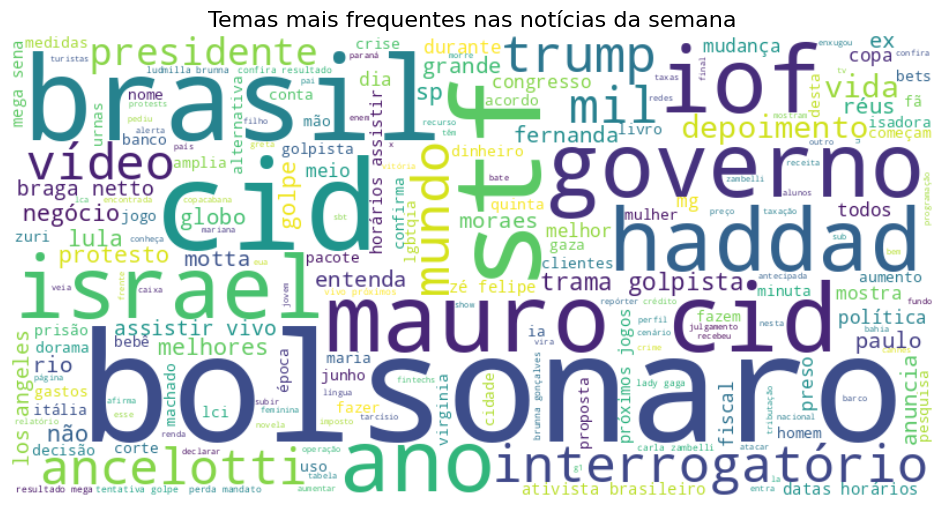

In [15]:
#Converter para pandas
top_words_pd = df_count.toPandas().head(20)

# Nuvem de palavras
texto_unico = " ".join(df["limpo"].tolist())
nuvem = WordCloud(width=800, height=400, background_color="white").generate(texto_unico)
plt.figure(figsize=(12, 6))
plt.imshow(nuvem, interpolation="bilinear")
plt.axis("off")
plt.title("Temas mais frequentes nas notícias da semana", fontsize=16)
plt.show()



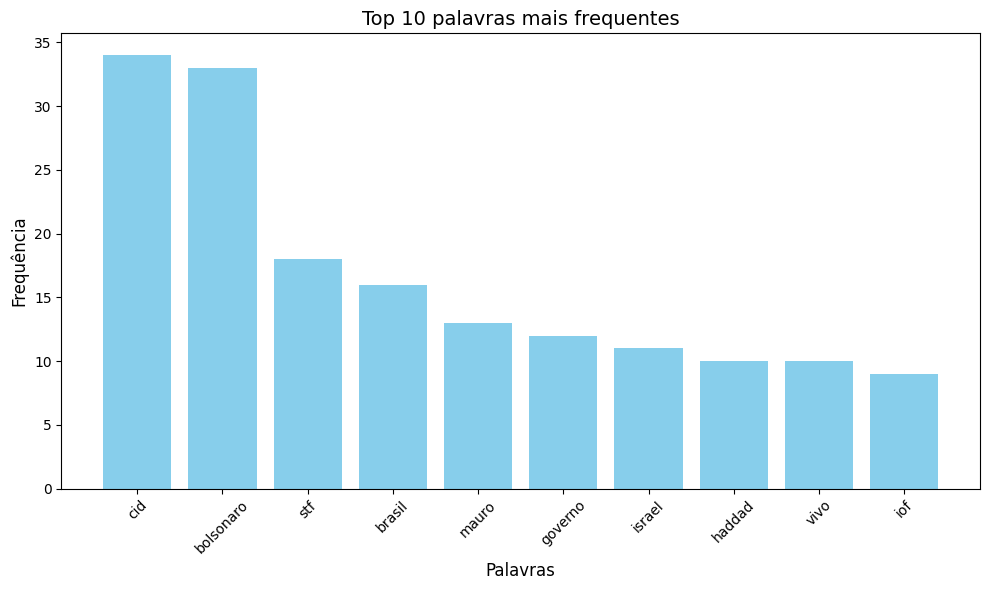

In [16]:
# Gráfico de barras das 10 palavras mais comuns
word_counts = Counter(texto_unico.split())
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color="skyblue")
plt.title("Top 10 palavras mais frequentes", fontsize=14)
plt.xlabel("Palavras", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()